# Exploratory Data Analysis

In [98]:
# Import necessary packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
import re
from collections import Counter
from nltk.corpus import stopwords
import nltk
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [99]:
# Read the csv file
df = pd.read_csv("DataSet.csv")

In [100]:
# View the first few rows
df.head()

,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,in_balanced_dataset
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"<h3>We're Food52, and we've created a groundbr...","<p>Food52, a fast-growing, James Beard Award-w...",<ul>\r\n<li>Experience with content management...,NaN,f,t,f,Other,Internship,NaN,NaN,Marketing,f,f
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"<h3>90 Seconds, the worlds Cloud Video Product...",<p>Organised - Focused - Vibrant - Awesome!<br...,<p><b>What we expect from you:</b></p>\r\n<p>Y...,<h3><b>What you will get from us</b></h3>\r\n<...,f,t,f,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,f,f
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,<h3></h3>\r\n<p>Valor Services provides Workfo...,"<p>Our client, located in Houston, is actively...",<ul>\r\n<li>Implement pre-commissioning and co...,NaN,f,t,f,NaN,NaN,NaN,NaN,NaN,f,f
3,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,<p>Our passion for improving quality of life t...,<p><b>THE COMPANY: ESRI – Environmental System...,<ul>\r\n<li>\r\n<b>EDUCATION: </b>Bachelor’s o...,<p>Our culture is anything but corporate—we ha...,f,t,f,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,f,f
4,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,<p>SpotSource Solutions LLC is a Global Human ...,<p><b>JOB TITLE:</b> Itemization Review Manage...,<p><b>QUALIFICATIONS:</b></p>\r\n<ul>\r\n<li>R...,<p>Full Benefits Offered</p>,f,t,t,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,f,f


In [101]:
# Get column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   title                17880 non-null  object
 1   location             17534 non-null  object
 2   department           6333 non-null   object
 3   salary_range         2868 non-null   object
 4   company_profile      14572 non-null  object
 5   description          17880 non-null  object
 6   requirements         15191 non-null  object
 7   benefits             10684 non-null  object
 8   telecommuting        17880 non-null  object
 9   has_company_logo     17880 non-null  object
 10  has_questions        17880 non-null  object
 11  employment_type      14409 non-null  object
 12  required_experience  10830 non-null  object
 13  required_education   9775 non-null   object
 14  industry             12977 non-null  object
 15  function             11425 non-null  object
 16  frau

In [102]:
# Drop all duplicate rows, keeping the first occurrence
df = df.drop_duplicates(keep='first')

# Check the new shape
print(f"New dataset shape: {df.shape}")


New dataset shape: (17645, 18)


In [103]:
# Convert columns to their appropriate data types

# Binary columns: convert 't'/'f' to 1/0 integers
binary_cols = [
    'telecommuting', 'has_company_logo', 'has_questions', 
    'fraudulent', 'in_balanced_dataset'
]

for col in binary_cols:
    df[col] = df[col].map({'t': 1, 'f': 0}).astype('Int64')

# Categorical columns: convert to 'category' dtype
categorical_cols = [
    'employment_type', 'required_experience', 'required_education', 
    'industry', 'function', 'department', 'location'
]
df[categorical_cols] = df[categorical_cols].astype('category')



In [104]:
# Check that the data types are converted correctly
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17645 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   title                17645 non-null  object  
 1   location             17302 non-null  category
 2   department           6283 non-null   category
 3   salary_range         2832 non-null   object  
 4   company_profile      14358 non-null  object  
 5   description          17645 non-null  object  
 6   requirements         14995 non-null  object  
 7   benefits             10542 non-null  object  
 8   telecommuting        17645 non-null  Int64   
 9   has_company_logo     17645 non-null  Int64   
 10  has_questions        17645 non-null  Int64   
 11  employment_type      14210 non-null  category
 12  required_experience  10669 non-null  category
 13  required_education   9617 non-null   category
 14  industry             12796 non-null  category
 15  function             112

In [105]:
# Drop the salary_range column as it contains mainly null values.
df = df.drop(columns=['salary_range'])

# Drop in_balanced_dataset column as it does not provide any info
df = df.drop(columns=['in_balanced_dataset'])

title: CUSTOMER SERVICE AGENT 
location: US, TX, DALLAS
department: nan
company_profile: <p>Aegis is a global business services provider in the area of experience management. We provide a suite of solutions for our clients, from strategy and design to implementation and execution, that help global brands deliver memorable end-customer experiences.</p>
<p>With a presence in 56 locations across 13 countries and with more than 55,000 employees, Aegis manages over a billion customer interactions every year for over 300 clients across verticals such as BFSI, Telecom, Healthcare, Travel and Hospitality, Consumer Goods, Retail, and Technology. Aegis manages, enables, extends, and enhances business experiences for its clients and their customers across consulting, technology, outsourcing, and training and education.</p>
<p>Aegis is an Essar enterprise. Essar is a USD 39 billion conglomerate.</p>
<p>- See more at: #URL_e8c499d2ca1fbf5755d4b1b178935b9083dccbe9587203a143de4981e0d2481a###URL_96e4f
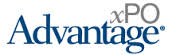

In [106]:
# Show all columns for 10 random fraud rows
fraud_samples = df[df['fraudulent'] == 1].sample(10, random_state=42)

for i, row in fraud_samples.iterrows():
    print("="*120)
    for col, val in row.items():
        print(f"{col}: {val}")
    print("="*120 + "\n")


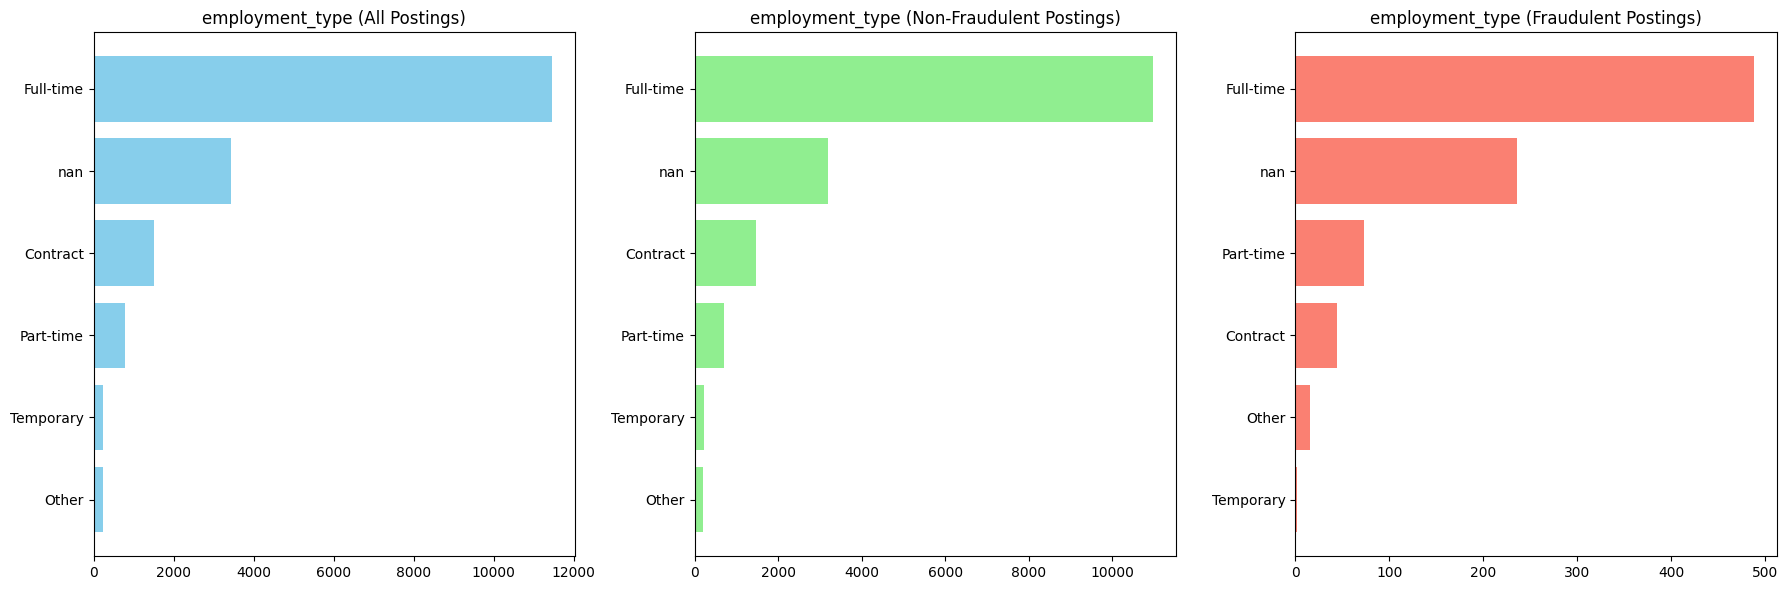

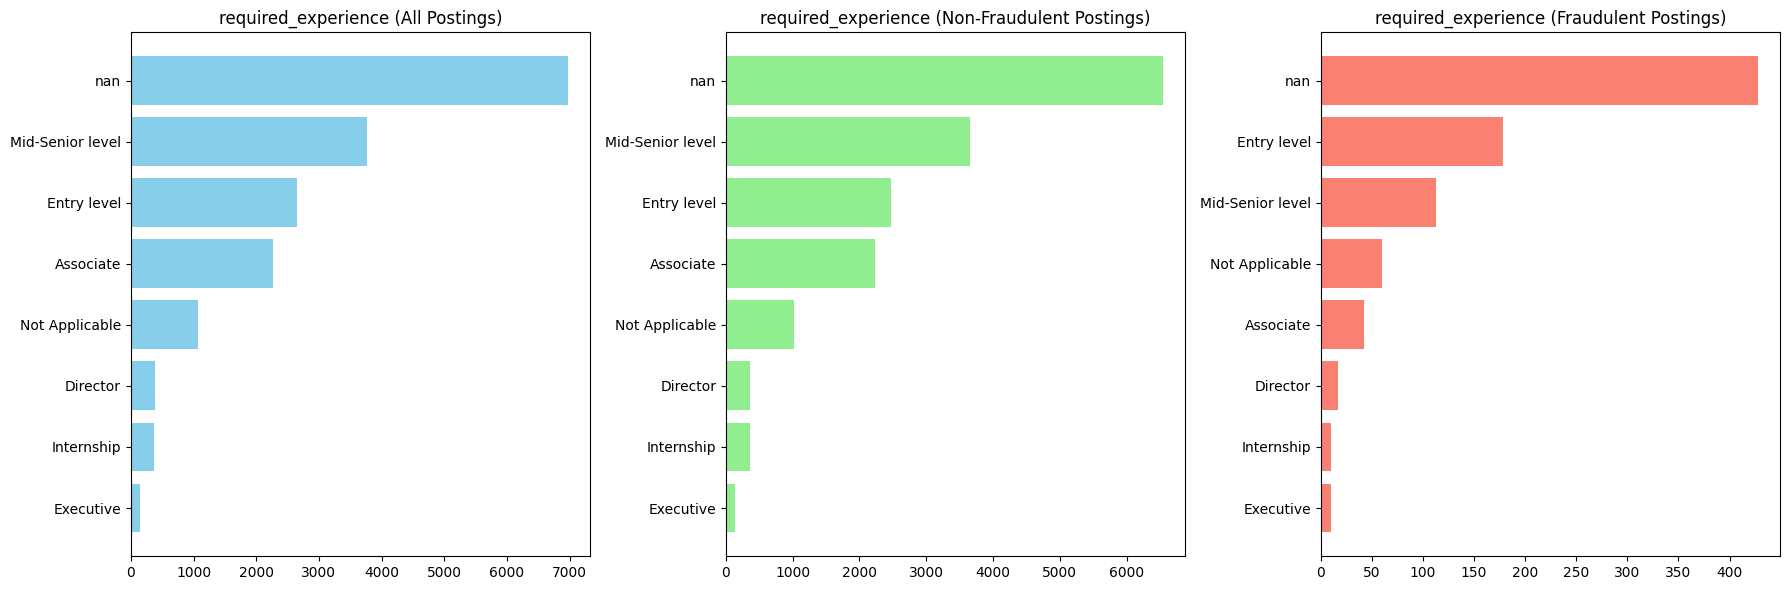

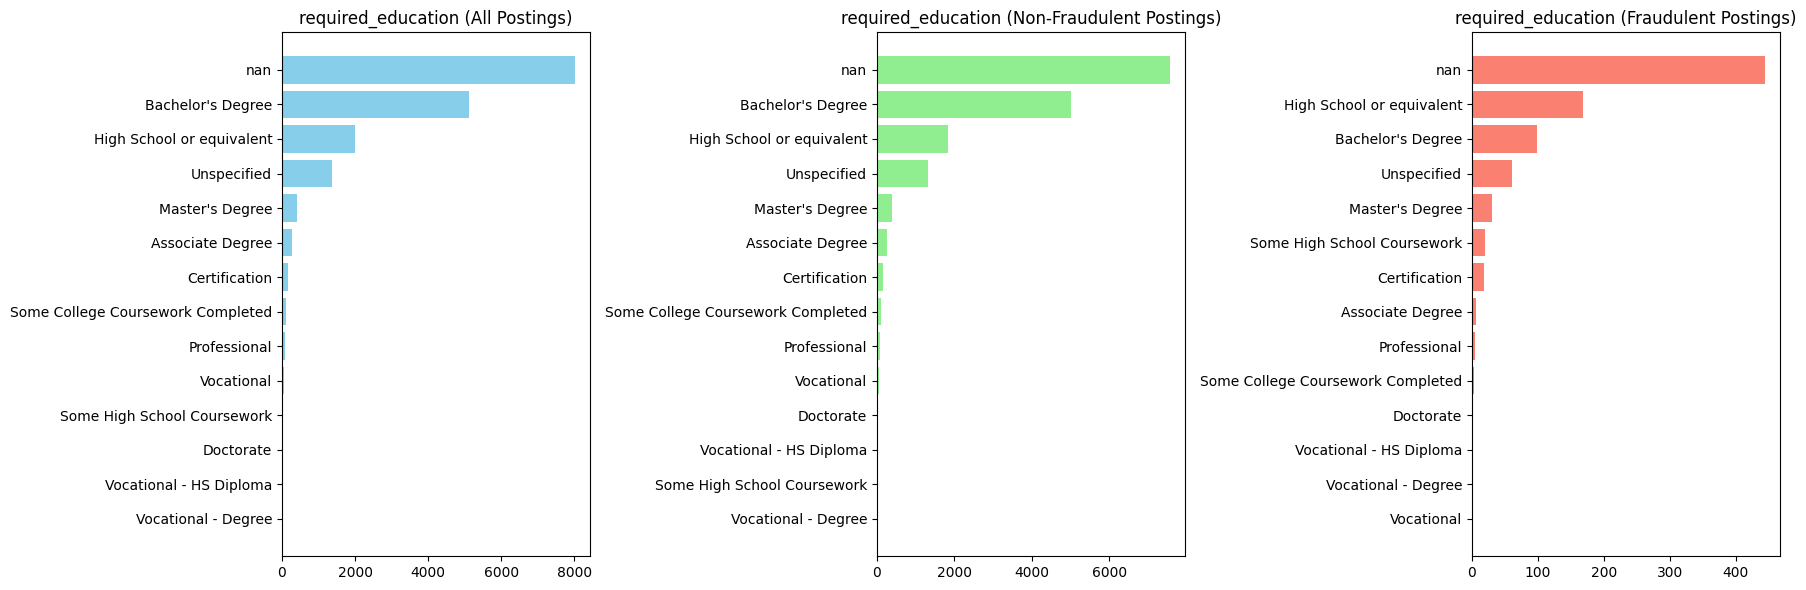

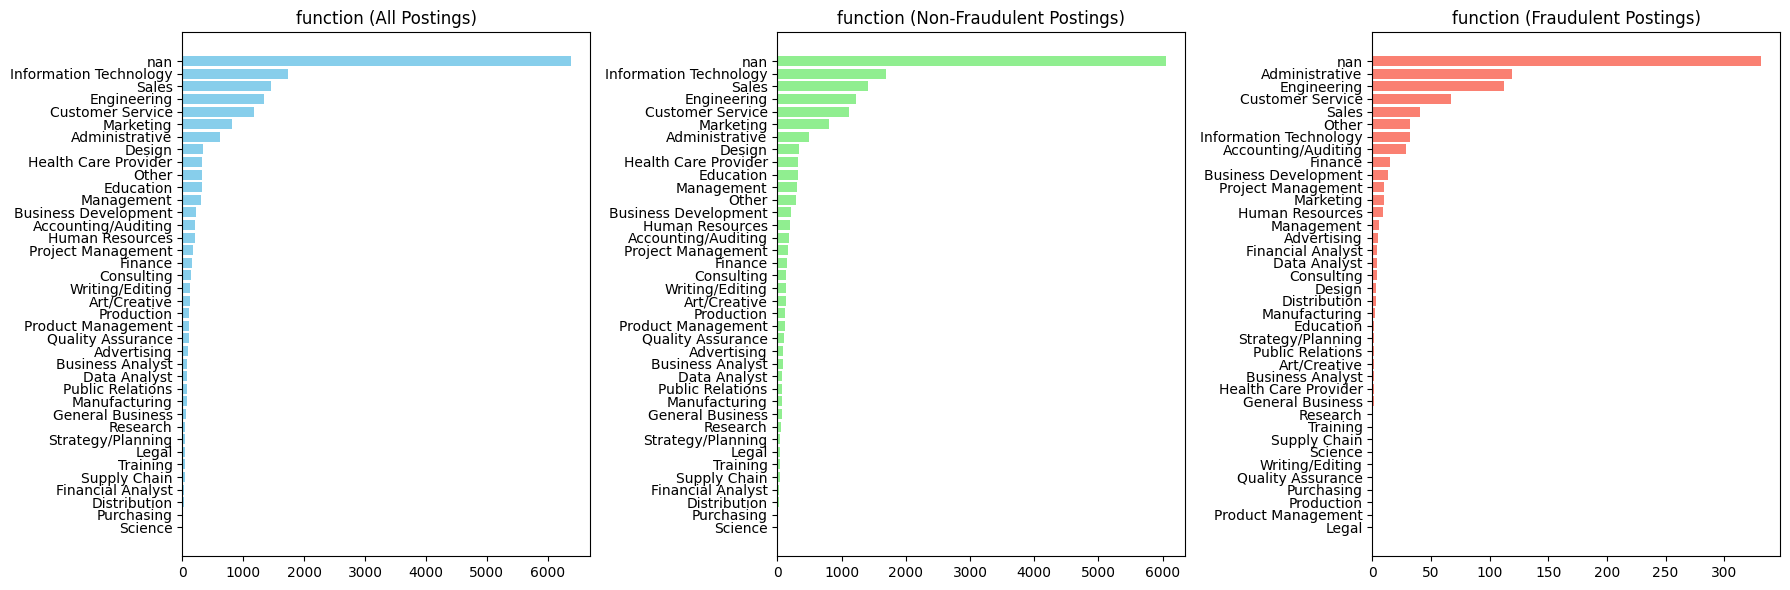

In [107]:
# Bar plots for employment_type, required_experience, required_education and function columns. 
# Plots are segmented Fraud, Non-Fraud and Fraud + Non-Fraud.
# We include NAs as it might provide useful information in identifying fraud cases.

categorical_cols = [
    'employment_type', 'required_experience', 'required_education', 'function'
]

for col in categorical_cols:
    # Compute counts for each segment (include NaNs) and sort descending
    overall_counts = df[col].value_counts(dropna=False).sort_values(ascending=True)
    non_fraud_counts = df[df['fraudulent']==0][col].value_counts(dropna=False).sort_values(ascending=True)
    fraud_counts = df[df['fraudulent']==1][col].value_counts(dropna=False).sort_values(ascending=True)
    
    # Create side-by-side subplots
    fig, axes = plt.subplots(1, 3, figsize=(18,6), sharey=False)
    
    # Overall
    axes[0].barh(overall_counts.index.astype(str), overall_counts.values, color='skyblue')
    axes[0].set_title(f'{col} (All Postings)')
    
    # Non-fraud
    axes[1].barh(non_fraud_counts.index.astype(str), non_fraud_counts.values, color='lightgreen')
    axes[1].set_title(f'{col} (Non-Fraudulent Postings)')
    
    # Fraud
    axes[2].barh(fraud_counts.index.astype(str), fraud_counts.values, color='salmon')
    axes[2].set_title(f'{col} (Fraudulent Postings)')
    
    plt.tight_layout()
    plt.show()


By segmenting postings into fraud and non-fraud, we observe that:
1) For employment types, fraud and non-fraud postings follow broadly similar trends.
2) For experience level, fraud postings target entry level candidates as compared to legitimate ones which focuses on a Mid-Senior level.
3) For education level, fraud postings generally have lower education requirements (High School) as compared to legitimate postings (Bachelor Degree)
4) For job functions, fraud postings are more common in administrative roles.

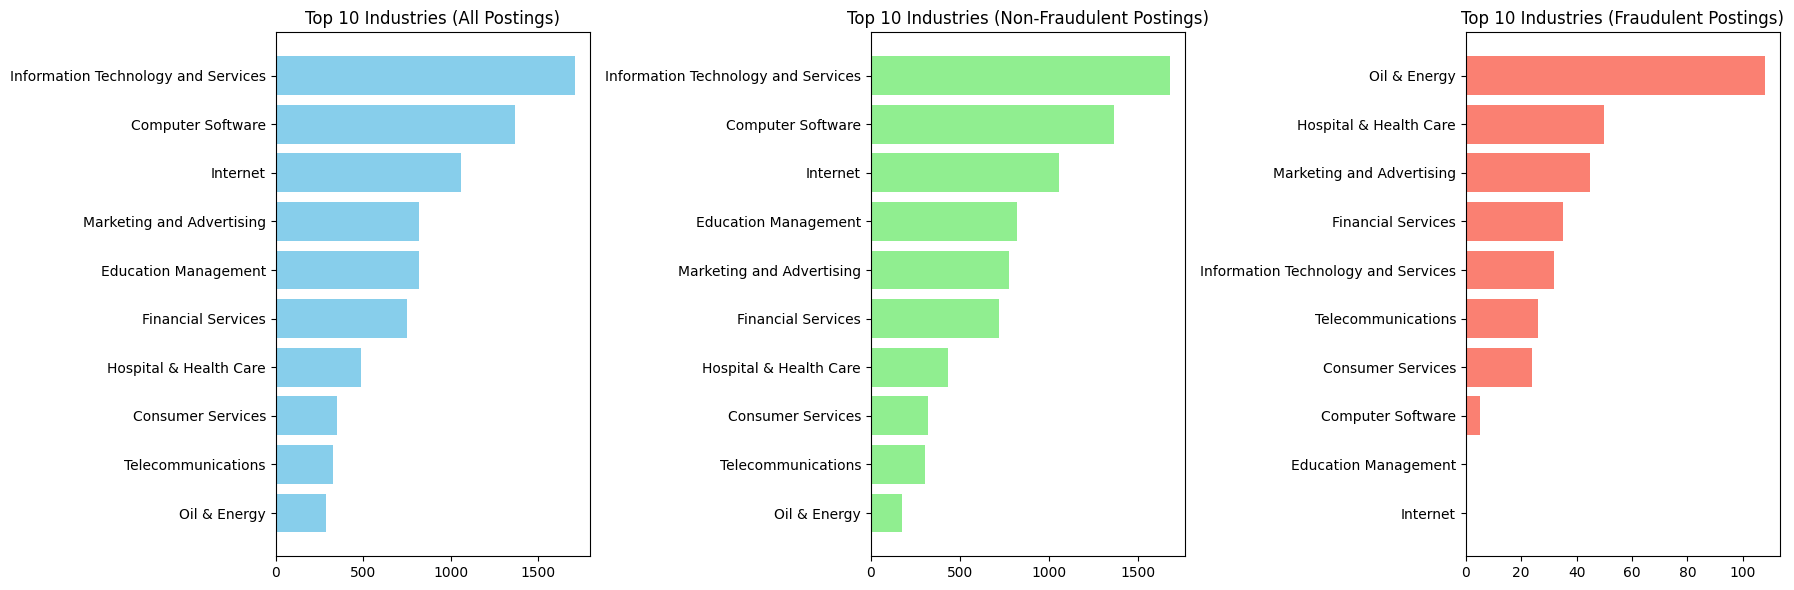

In [108]:
# Bar plot for Top 10 industries
top10_industry = df['industry'].value_counts().nlargest(10).index

# Overall counts
overall_counts = df['industry'].value_counts().loc[top10_industry].sort_values(ascending=True)

# Non-fraud counts
non_fraud_counts = (
    df[df['fraudulent']==0]['industry']
    .value_counts()
    .reindex(top10_industry, fill_value=0)
    .sort_values(ascending=True)
)

# Fraud counts
fraud_counts = (
    df[df['fraudulent']==1]['industry']
    .value_counts()
    .reindex(top10_industry, fill_value=0)
    .sort_values(ascending=True)
)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18,6))

axes[0].barh(overall_counts.index, overall_counts.values, color='skyblue')
axes[0].set_title('Top 10 Industries (All Postings)')

axes[1].barh(non_fraud_counts.index, non_fraud_counts.values, color='lightgreen')
axes[1].set_title('Top 10 Industries (Non-Fraudulent Postings)')

axes[2].barh(fraud_counts.index, fraud_counts.values, color='salmon')
axes[2].set_title('Top 10 Industries (Fraudulent Postings)')

plt.tight_layout()
plt.show()


There is an obvious concentration of fraud postings in Oil & Energy, suggesting targeted exploitation of this sector. This acts as a signal to distinguish between scam job ads from legitimate ones.

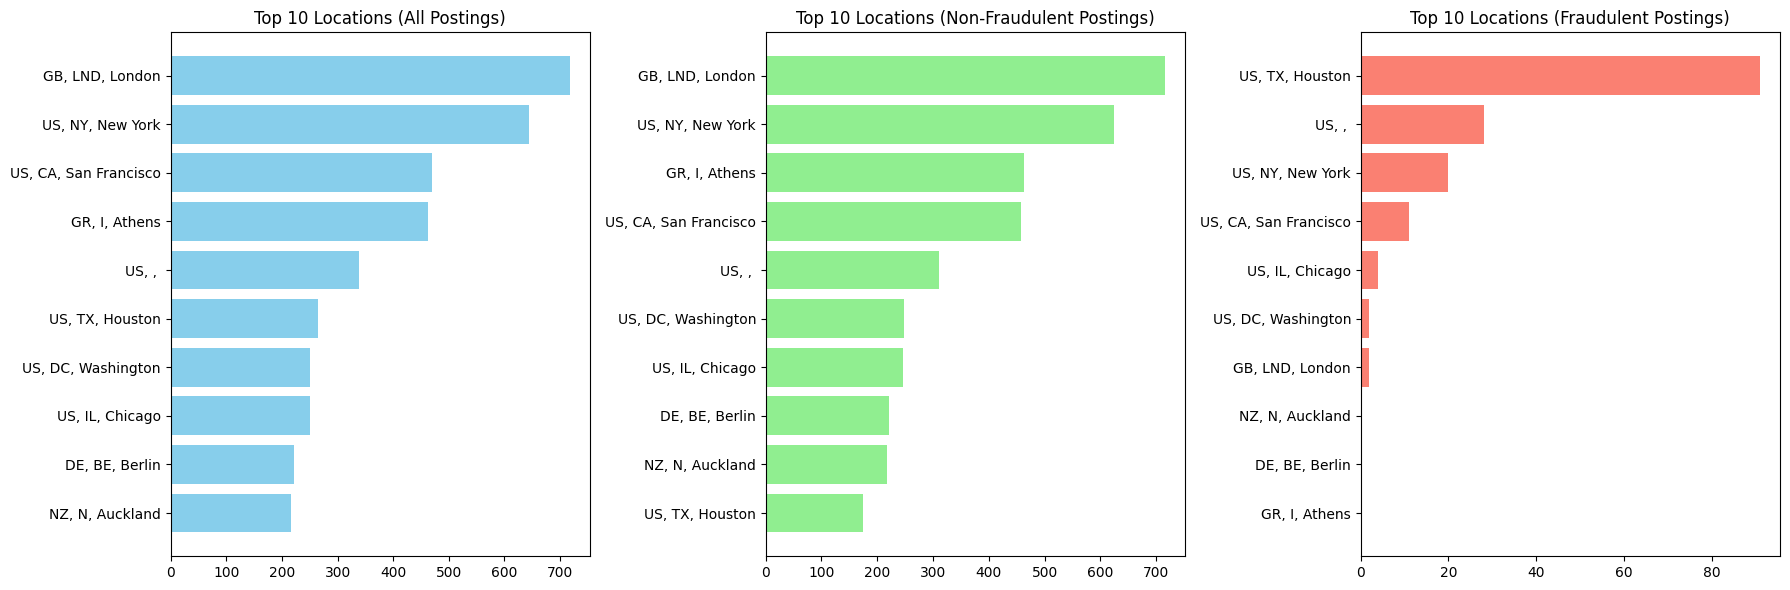

In [109]:
# Bar plot for Top 10 locations
top10_location = df['location'].value_counts().nlargest(10).index

# Overall counts
overall_counts = df['location'].value_counts().loc[top10_location].sort_values(ascending=True)

# Non-fraud counts
non_fraud_counts = (
    df[df['fraudulent']==0]['location']
    .value_counts()
    .reindex(top10_location, fill_value=0)
    .sort_values(ascending=True)
)

# Fraud counts
fraud_counts = (
    df[df['fraudulent']==1]['location']
    .value_counts()
    .reindex(top10_location, fill_value=0)
    .sort_values(ascending=True)
)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18,6))
axes[0].barh(overall_counts.index, overall_counts.values, color='skyblue')
axes[0].set_title('Top 10 Locations (All Postings)')
axes[1].barh(non_fraud_counts.index, non_fraud_counts.values, color='lightgreen')
axes[1].set_title('Top 10 Locations (Non-Fraudulent Postings)')
axes[2].barh(fraud_counts.index, fraud_counts.values, color='salmon')
axes[2].set_title('Top 10 Locations (Fraudulent Postings)')
plt.tight_layout()
plt.show()


Similarly, an obvious concentration of fraud postings in "US, TX, Houston" is seen from the plot above.

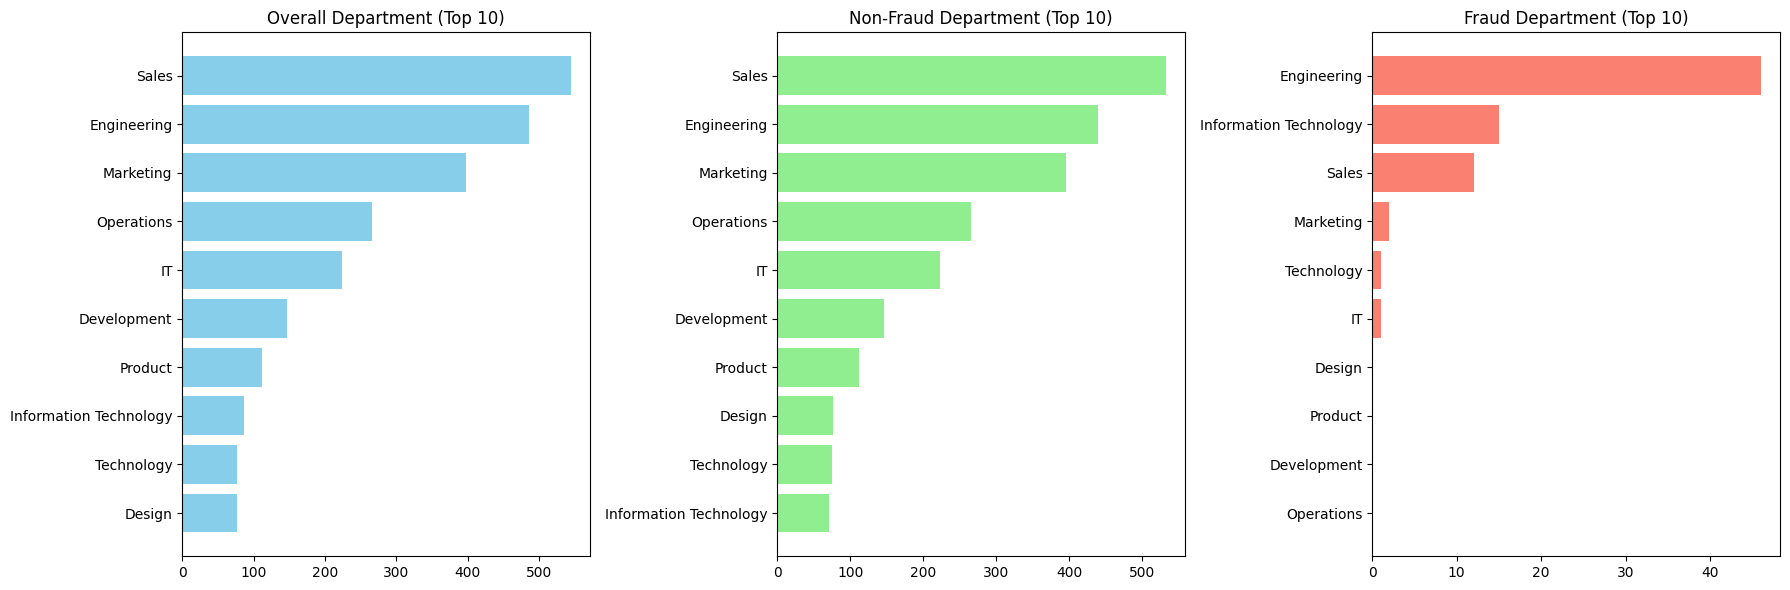

In [110]:
# Bar plot for Top 10 departments
top10_department = df['department'].value_counts().nlargest(10).index

# Overall counts
overall_counts = df['department'].value_counts().loc[top10_department].sort_values(ascending=True)

# Non-fraud counts
non_fraud_counts = (
    df[df['fraudulent']==0]['department']
    .value_counts()
    .reindex(top10_department, fill_value=0)
    .sort_values(ascending=True)
)

# Fraud counts
fraud_counts = (
    df[df['fraudulent']==1]['department']
    .value_counts()
    .reindex(top10_department, fill_value=0)
    .sort_values(ascending=True)
)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18,6))
axes[0].barh(overall_counts.index, overall_counts.values, color='skyblue')
axes[0].set_title('Overall Department (Top 10)')
axes[1].barh(non_fraud_counts.index, non_fraud_counts.values, color='lightgreen')
axes[1].set_title('Non-Fraud Department (Top 10)')
axes[2].barh(fraud_counts.index, fraud_counts.values, color='salmon')
axes[2].set_title('Fraud Department (Top 10)')
plt.tight_layout()
plt.show()


Fraud postings see a concentration in engineering, which is similar to the distribution in legitimate postings. Moreover, mostly missing values (~2/3) in this feature. Hence, we will drop this column in future analysis.

In [111]:
# Drop the department column as it has about 2/3 missing values and do not provide trends into fraud cases.
df = df.drop(columns=['department'])

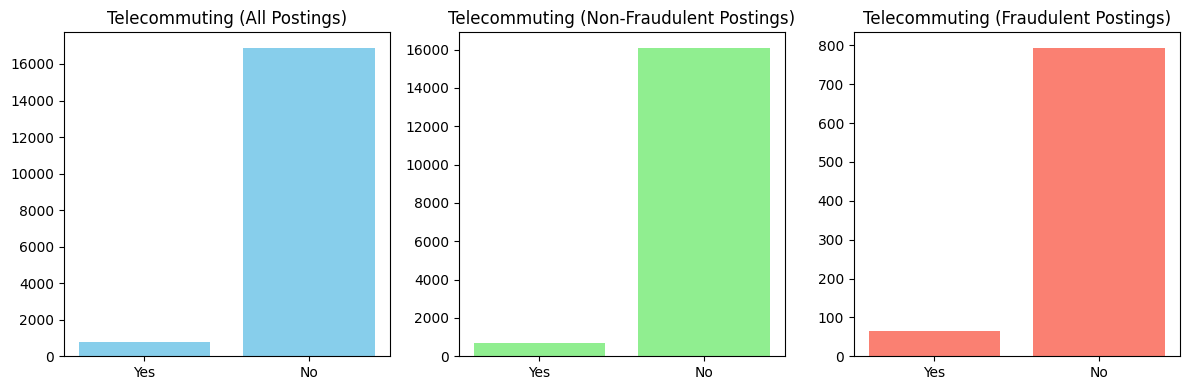

In [112]:
# Bar plot for Telecommuting
col = 'telecommuting'
labels = {0: "No", 1: "Yes"}

overall_counts = df[col].map(labels).value_counts(dropna=False).sort_values(ascending=True)
non_fraud_counts = df.loc[df['fraudulent'] == 0, col].map(labels).value_counts(dropna=False).sort_values(ascending=True)
fraud_counts = df.loc[df['fraudulent'] == 1, col].map(labels).value_counts(dropna=False).sort_values(ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].bar(overall_counts.index, overall_counts.values, color='skyblue')
axes[0].set_title('Telecommuting (All Postings)')
axes[1].bar(non_fraud_counts.index, non_fraud_counts.values, color='lightgreen')
axes[1].set_title('Telecommuting (Non-Fraudulent Postings)')
axes[2].bar(fraud_counts.index, fraud_counts.values, color='salmon')
axes[2].set_title('Telecommuting (Fraudulent Postings)')
plt.tight_layout()
plt.show()


Distributions are similar between fraud and non-fraud. Consider dropping this feature in model development.

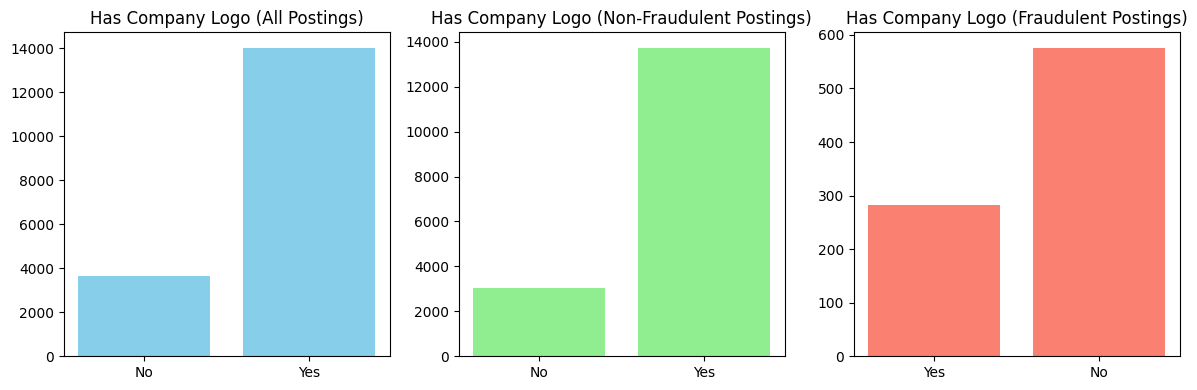

In [113]:
# Bar plot for has_company_logo
col = 'has_company_logo'
labels = {0: "No", 1: "Yes"}

overall_counts = df[col].map(labels).value_counts(dropna=False).sort_values(ascending=True)
non_fraud_counts = df.loc[df['fraudulent'] == 0, col].map(labels).value_counts(dropna=False).sort_values(ascending=True)
fraud_counts = df.loc[df['fraudulent'] == 1, col].map(labels).value_counts(dropna=False).sort_values(ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].bar(overall_counts.index, overall_counts.values, color='skyblue')
axes[0].set_title('Has Company Logo (All Postings)')
axes[1].bar(non_fraud_counts.index, non_fraud_counts.values, color='lightgreen')
axes[1].set_title('Has Company Logo (Non-Fraudulent Postings)')
axes[2].bar(fraud_counts.index, fraud_counts.values, color='salmon')
axes[2].set_title('Has Company Logo (Fraudulent Postings)')
plt.tight_layout()
plt.show()


Bar plot shows that most fraud postings have no company logo, while legitimate postings have a company logo. This acts as a signal to distinguish between scam job ads from legitimate ones.

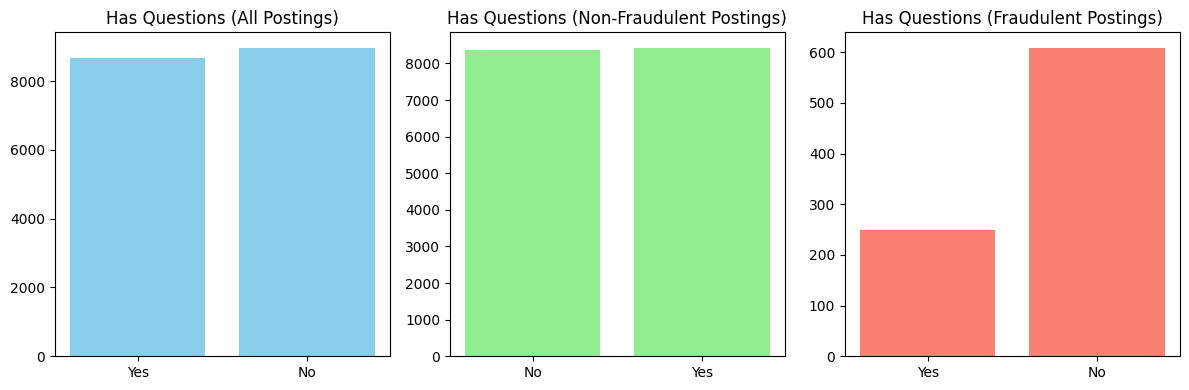

In [114]:
# Bar plot for has_questions
col = 'has_questions'
labels = {0: "No", 1: "Yes"}

overall_counts = df[col].map(labels).value_counts(dropna=False).sort_values(ascending=True)
non_fraud_counts = df.loc[df['fraudulent'] == 0, col].map(labels).value_counts(dropna=False).sort_values(ascending=True)
fraud_counts = df.loc[df['fraudulent'] == 1, col].map(labels).value_counts(dropna=False).sort_values(ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].bar(overall_counts.index, overall_counts.values, color='skyblue')
axes[0].set_title('Has Questions (All Postings)')
axes[1].bar(non_fraud_counts.index, non_fraud_counts.values, color='lightgreen')
axes[1].set_title('Has Questions (Non-Fraudulent Postings)')
axes[2].bar(fraud_counts.index, fraud_counts.values, color='salmon')
axes[2].set_title('Has Questions (Fraudulent Postings)')
plt.tight_layout()
plt.show()


Distributions differ between fraud and non-fraud postings. However, the definition of this feature is unclear. We will need to validate its meaning with the data source before deciding to retain or drop it.

In [115]:
# Null value counts for company_profile segmented by fraud vs non-fraud
null_summary = (
    df.groupby('fraudulent')['company_profile']
      .apply(lambda x: x.isna().sum())
      .reset_index(name='null_count')
)

non_null_summary = (
    df.groupby('fraudulent')['company_profile']
      .apply(lambda x: x.notna().sum())
      .reset_index(name='non_null_count')
)

# Merge together
summary = pd.merge(null_summary, non_null_summary, on='fraudulent')
summary['total'] = summary['null_count'] + summary['non_null_count']
summary['null_pct'] = summary['null_count'] / summary['total'] * 100

print(summary)


   fraudulent  null_count  non_null_count  total   null_pct
0           0        2706           14081  16787  16.119616
1           1         581             277    858  67.715618


In [116]:
# For fraud cases, company_profile is almost 68% missing. This absence itself may serve as a useful fraud signal.
# Create a new column has_company_profile (1 if exists, 0 if missing)

df['has_company_profile'] = df['company_profile'].notnull().astype(int)

# Drop the company_profile column
df = df.drop(columns=['company_profile'])

# Quick check by fraud status
print(df.groupby('fraudulent')['has_company_profile'].value_counts(normalize=True))


fraudulent  has_company_profile
0           1                      0.838804
            0                      0.161196
1           0                      0.677156
            1                      0.322844
Name: proportion, dtype: float64


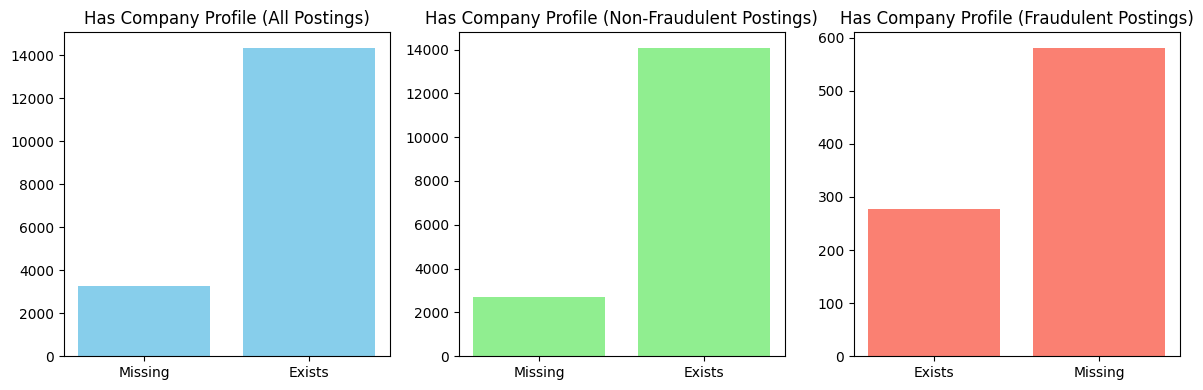

In [117]:
# Bar plot for has_company_profile

# Map 0/1 to labels
labels = {0: "Missing", 1: "Exists"}

# Prepare counts
overall_counts = df['has_company_profile'].map(labels).value_counts().sort_values(ascending=True)
non_fraud_counts = df[df['fraudulent']==0]['has_company_profile'].map(labels).value_counts().sort_values(ascending=True)
fraud_counts = df[df['fraudulent']==1]['has_company_profile'].map(labels).value_counts().sort_values(ascending=True)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(12,4))

axes[0].bar(overall_counts.index, overall_counts.values, color='skyblue')
axes[0].set_title('Has Company Profile (All Postings)')

axes[1].bar(non_fraud_counts.index, non_fraud_counts.values, color='lightgreen')
axes[1].set_title('Has Company Profile (Non-Fraudulent Postings)')

axes[2].bar(fraud_counts.index, fraud_counts.values, color='salmon')
axes[2].set_title('Has Company Profile (Fraudulent Postings)')

plt.tight_layout()
plt.show()

Bar plot shows that fraud postings generally have missing company profiles, and this serves as an indicator to distinguish between scam job ads from legitimate ones.

In [118]:
# Analysis on text data
# Perform text cleaning on the "description", "requirements", "benefits" columns.
# Cleaning steps include: Removing HTML tags, lowercasing text, remove numbers, remove long special character sequences, normalizing spaces.

def clean_html(text):
    if pd.isna(text):
        return ""
    
    # Parse HTML
    soup = BeautifulSoup(text, "html.parser")
    clean_text = soup.get_text(separator=" ")
    
    # Replace multiple spaces with single space
    clean_text = " ".join(clean_text.split())
    
    # Convert to lowercase
    clean_text = clean_text.lower()
    
    # Remove numbers
    clean_text = re.sub(r'\d+', '', clean_text)
    
    # Remove repeated underscores or long sequences of special characters
    clean_text = re.sub(r'[_\W]{2,}', ' ', clean_text)
    
    # Normalize spaces again after removals
    clean_text = " ".join(clean_text.split())
    
    return clean_text

# Apply to columns
df['clean_description'] = df['description'].apply(clean_html)
df['clean_requirements'] = df['requirements'].apply(clean_html)
df['clean_benefits'] = df['benefits'].apply(clean_html)

# Preview
df[['clean_description', 'clean_requirements', 'clean_benefits']].head()


,clean_description,clean_requirements,clean_benefits
0,food a fast-growing james beard award-winning ...,experience with content management systems a m...,
1,organised focused vibrant awesome do you have ...,what we expect from you your key responsibilit...,what you will get from us through being part o...
2,our client located in houston is actively seek...,implement pre-commissioning and commissioning ...,
3,the company esri environmental systems researc...,education bachelor’s or master’s in gis busine...,our culture is anything but corporate—we have ...
4,job title itemization review manager location ...,qualifications rn license in the state of texa...,full benefits offered


In [119]:
# Create columns for word count for the three text columns
df['desc_word_count'] = df['clean_description'].apply(lambda x: len(x.split()))
df['req_word_count'] = df['clean_requirements'].apply(lambda x: len(x.split()))
df['benef_word_count'] = df['clean_benefits'].apply(lambda x: len(x.split()))

In [120]:
# Summary statistics on Description word count
df.groupby('fraudulent')['desc_word_count'].describe()


,count,mean,std,min,25%,50%,75%,max
fraudulent,,,,,,,,
0,16787.0,175.957169,125.687784,6.0,90.00,151.0,231.0,2076.0
1,858.0,161.812354,139.176117,0.0,67.25,120.0,212.0,1180.0


In [121]:
# Summary statistics on Requirements word count
df.groupby('fraudulent')['req_word_count'].describe()

,count,mean,std,min,25%,50%,75%,max
fraudulent,,,,,,,,
0,16787.0,83.578305,85.876641,0.0,20.0,67.0,116.0,1638.0
1,858.0,60.803030,76.440654,0.0,8.0,35.0,88.0,513.0


In [122]:
# Summary statistics on Benefits word count
df.groupby('fraudulent')['benef_word_count'].describe()

,count,mean,std,min,25%,50%,75%,max
fraudulent,,,,,,,,
0,16787.0,30.986001,50.614374,0.0,0.0,6.0,43.0,663.0
1,858.0,29.824009,54.295299,0.0,0.0,5.0,36.0,395.0


On average, we see that fraud postings generally have a lower word count compared to non-fraud postings.

[nltk_data] Downloading package stopwords to /Users/jjong/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



--- Top words for clean_description ---


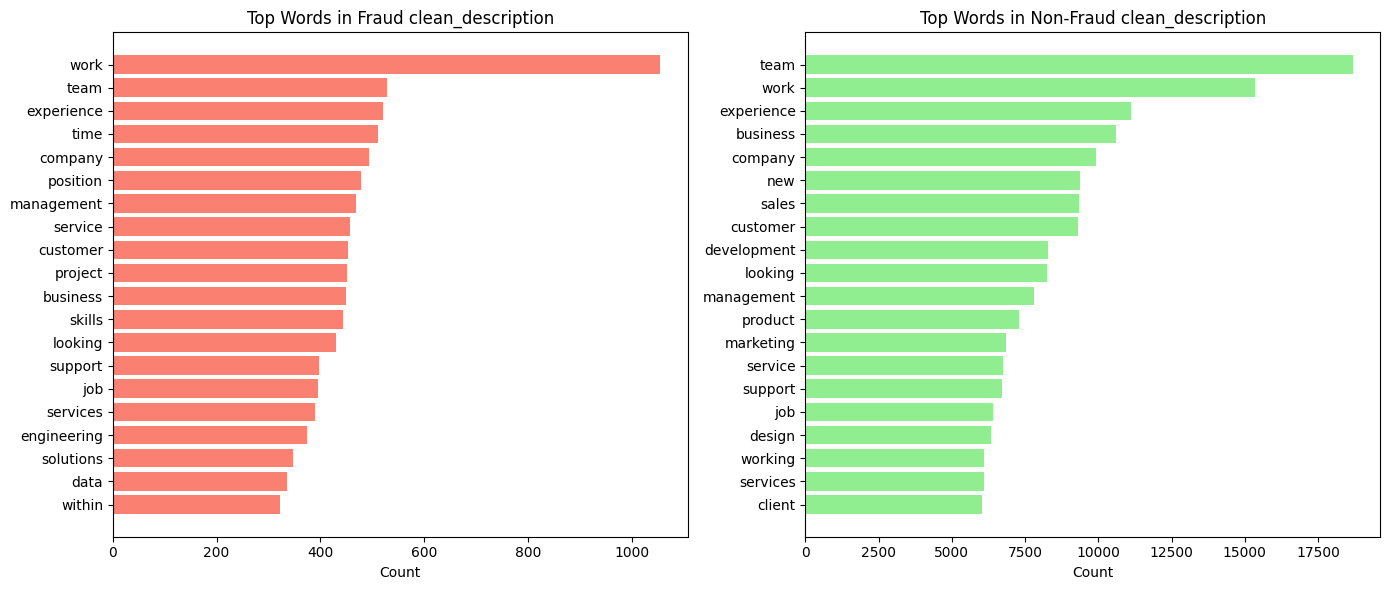


--- Top words for clean_requirements ---


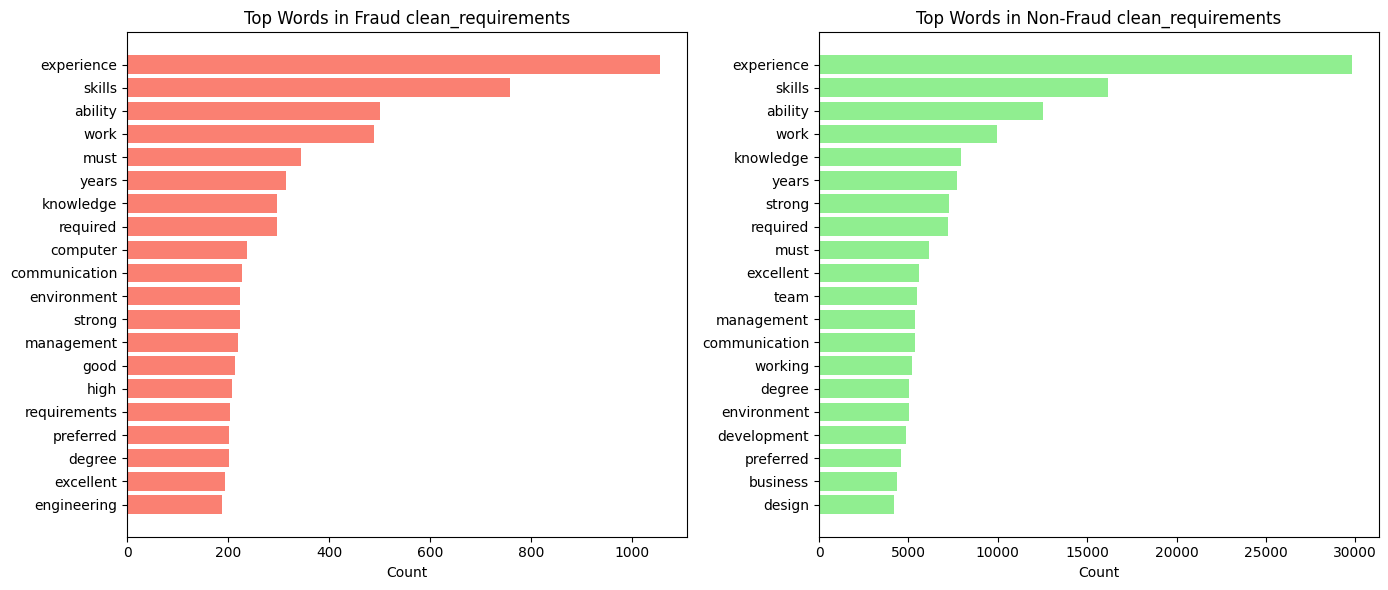


--- Top words for clean_benefits ---


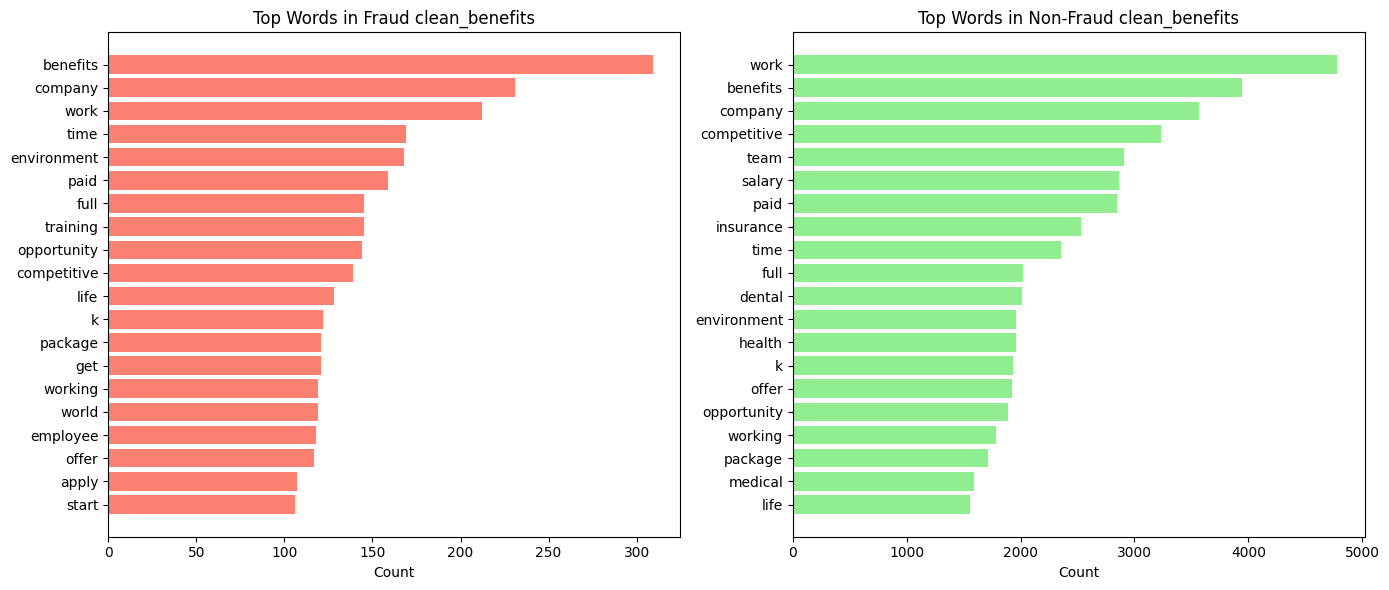

In [123]:
# Plot the top 20 used words within the description, requirements and benefits columns
# Download stopwords if not already
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Tokenizer with stopword removal
def tokenize(text):
    tokens = re.findall(r'\b\w+\b', text)  # split on word boundaries
    tokens = [t for t in tokens if t not in stop_words]
    return tokens

# Columns to analyze
text_cols = ['clean_description', 'clean_requirements', 'clean_benefits']

for col in text_cols:
    print(f"\n--- Top words for {col} ---")
    
    # Combine text per class
    fraud_text = " ".join(df[df['fraudulent']==1][col])
    non_fraud_text = " ".join(df[df['fraudulent']==0][col])
    
    # Count words
    fraud_counts = Counter(tokenize(fraud_text))
    non_fraud_counts = Counter(tokenize(non_fraud_text))
    
    # Convert to DataFrame for plotting
    fraud_df = pd.DataFrame(fraud_counts.most_common(20), columns=['word','count'])
    non_fraud_df = pd.DataFrame(non_fraud_counts.most_common(20), columns=['word','count'])
    
    # Plot side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(14,6))
    
    # Fraud top words
    axes[0].barh(fraud_df['word'][::-1], fraud_df['count'][::-1], color='salmon')
    axes[0].set_title(f"Top Words in Fraud {col}")
    axes[0].set_xlabel("Count")
    
    # Non-Fraud top words
    axes[1].barh(non_fraud_df['word'][::-1], non_fraud_df['count'][::-1], color='lightgreen')
    axes[1].set_title(f"Top Words in Non-Fraud {col}")
    axes[1].set_xlabel("Count")
    
    plt.tight_layout()
    plt.show()


Analyzing individual words (unigrams) in the text provides limited insights into patterns of fraudulent postings. To capture more meaningful phrases and contexts, we shift to analyzing n-grams in the text.


--- Top n-grams for clean_description ---


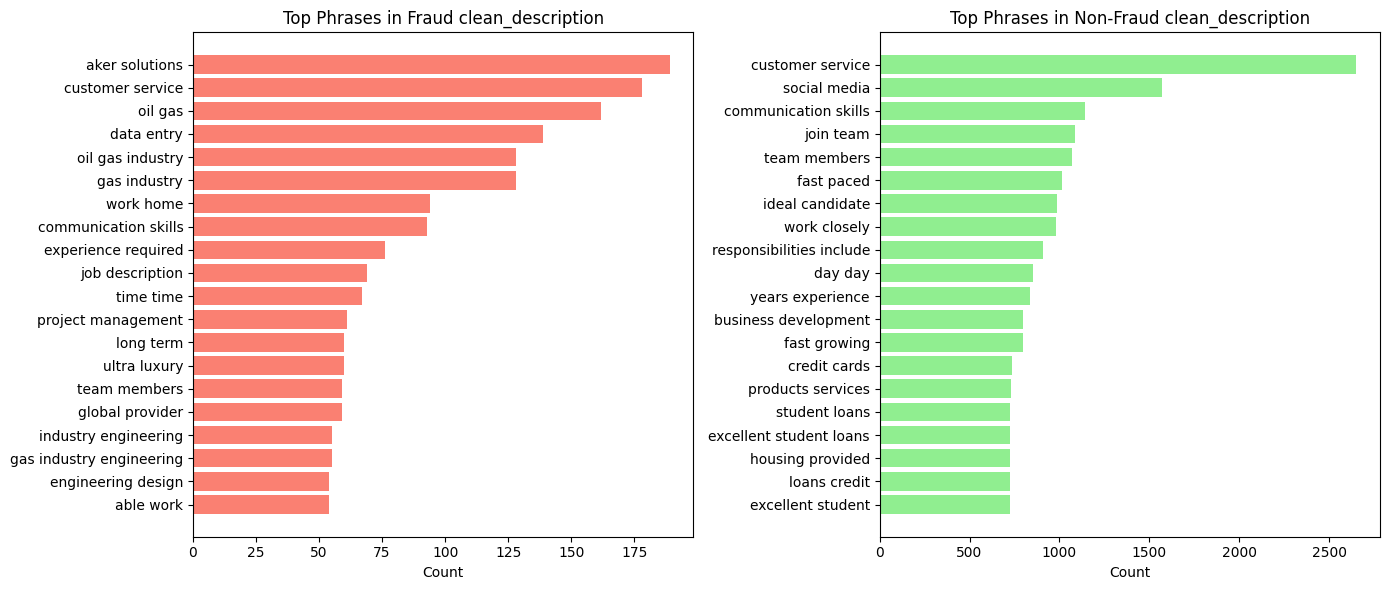


--- Top n-grams for clean_requirements ---


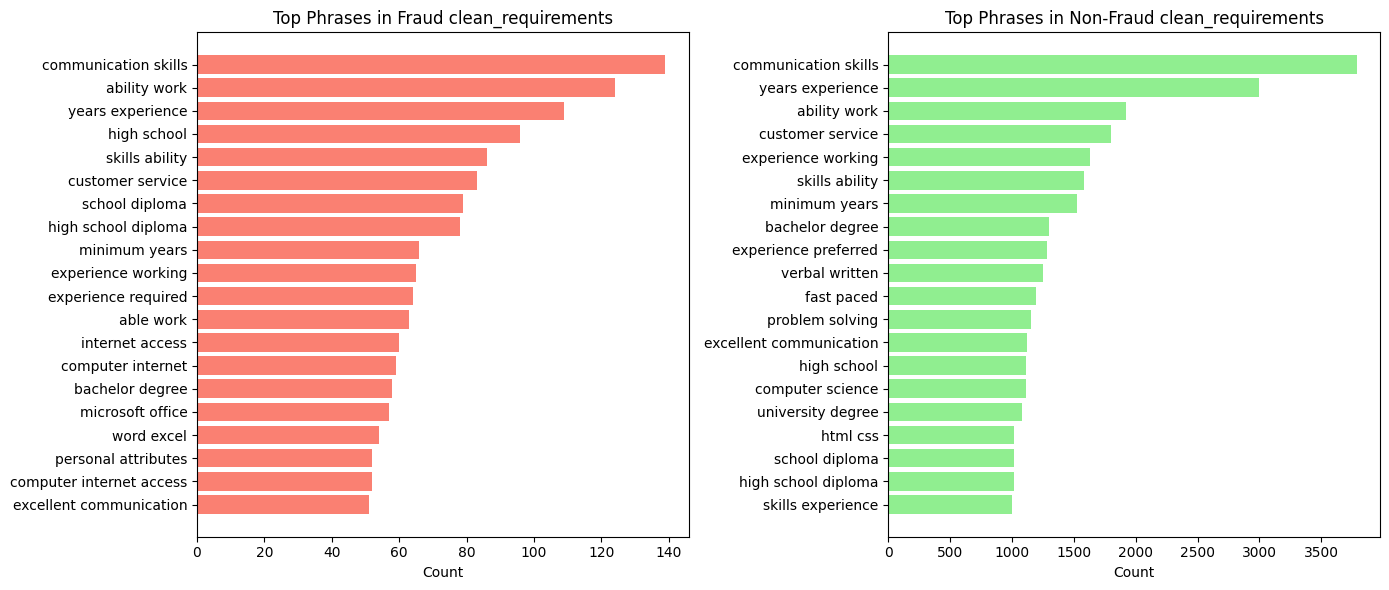


--- Top n-grams for clean_benefits ---


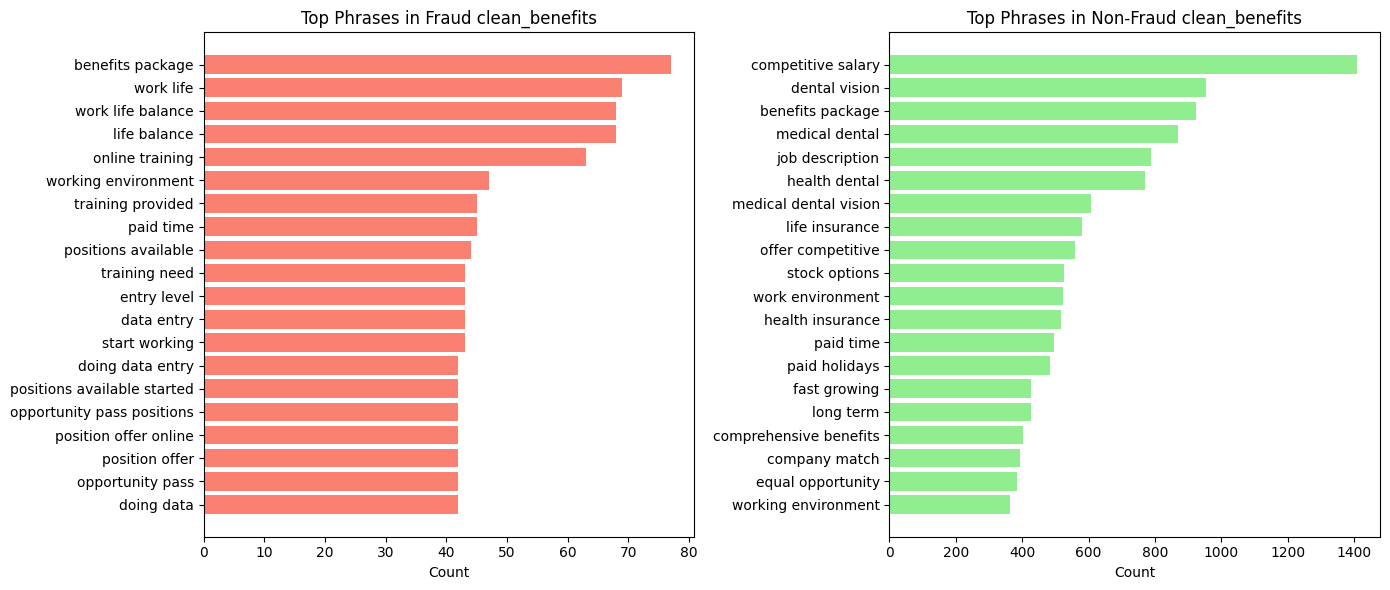

In [124]:
# Top N-grams in fraud and non fraud postings. We explore phrases of 2 to 3 words.

def get_top_ngrams(corpus, ngram_range=(2,3), top_n=20):
    """
    Returns top n-grams from a list of documents
    """
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    X = vectorizer.fit_transform(corpus)
    counts = X.sum(axis=0).A1
    features = vectorizer.get_feature_names_out()
    ngram_counts = pd.DataFrame({'ngram': features, 'count': counts})
    return ngram_counts.sort_values('count', ascending=False).head(top_n)

# Columns to analyze
text_cols = ['clean_description', 'clean_requirements', 'clean_benefits']

for col in text_cols:
    print(f"\n--- Top n-grams for {col} ---")
    
    # Prepare corpora
    fraud_corpus = df[df['fraudulent']==1][col].tolist()
    non_fraud_corpus = df[df['fraudulent']==0][col].tolist()
    
    # Get top n-grams
    fraud_ngrams = get_top_ngrams(fraud_corpus, ngram_range=(2,3), top_n=20)
    non_fraud_ngrams = get_top_ngrams(non_fraud_corpus, ngram_range=(2,3), top_n=20)
    
    # Plot side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(14,6))
    
    # Fraud
    axes[0].barh(fraud_ngrams['ngram'][::-1], fraud_ngrams['count'][::-1], color='salmon')
    axes[0].set_title(f"Top Phrases in Fraud {col}")
    axes[0].set_xlabel("Count")
    
    # Non-Fraud
    axes[1].barh(non_fraud_ngrams['ngram'][::-1], non_fraud_ngrams['count'][::-1], color='lightgreen')
    axes[1].set_title(f"Top Phrases in Non-Fraud {col}")
    axes[1].set_xlabel("Count")
    
    plt.tight_layout()
    plt.show()


More distinctive patterns are now revealed for fraud vs non fraud postings.

For job descriptions, 'aker solutions' is the most commonly used phrase (A follow up investigation reveals that this is a company name for a fraudulent job posting). Phrases like "oil gas" are also common, which is expected as we saw previously that Oil & Energy is the most common fraud industry. 

More generally, phrases like "work home", "ultra luxury" are also common phrases used to lure job seekers.

For job requirements, it is typically low skill focused, with phrases such as "high school", "internet access" to indicate minimal qualifications needed to apply for the job. This helps fraudulent job posters increase their target audience.

For job benefits, phrases like "benefits package", "work life balance" are common, which helps to attract job seekers in applying for those fraudulent jobs.

Using N-grams, we are able to identify common phrases within fraud and non-fraud postings. However, some phrases might be common across the 2 groups, and hence the common phrases might not be an indicative sign to distinguish scam job ads from legitimate ones.

Instead, we explore using TF-IDF to measure how distinctive each phrase is for fraud postings compared to non-fraud postings. This approach highlights phrases that are more characteristic of scam job ads, helping to better distinguish between them from legitimate postings.

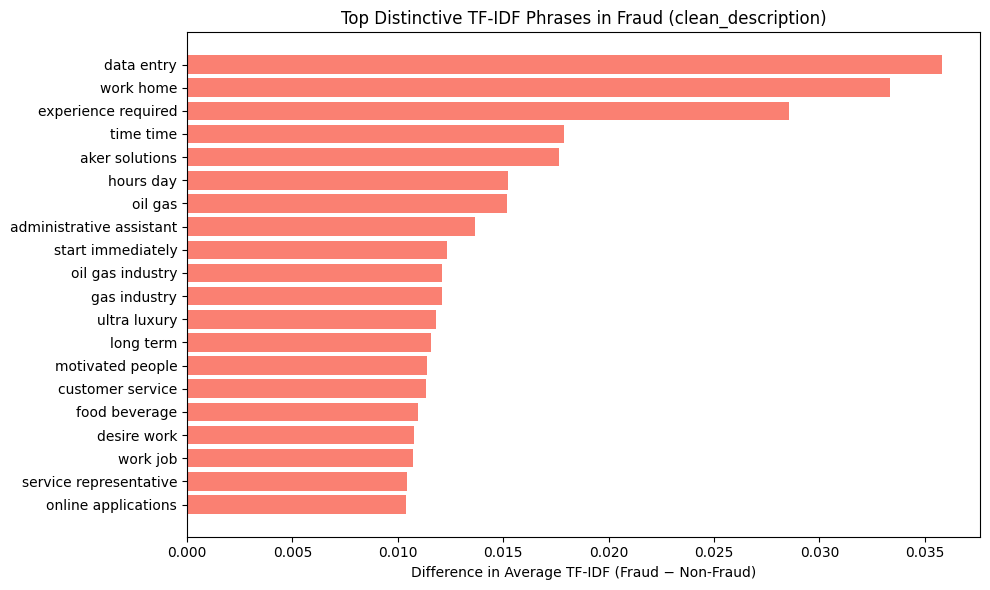

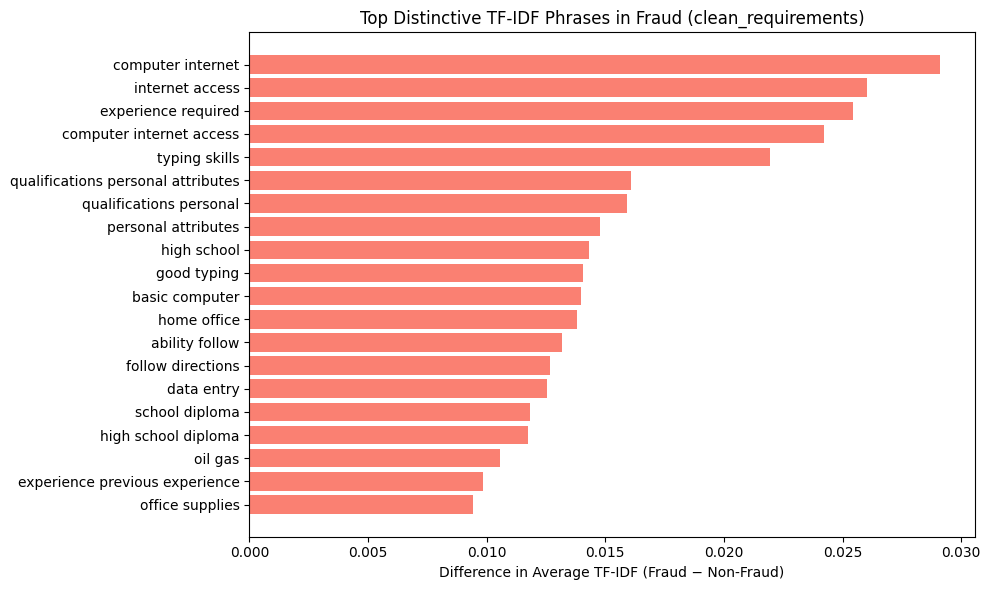

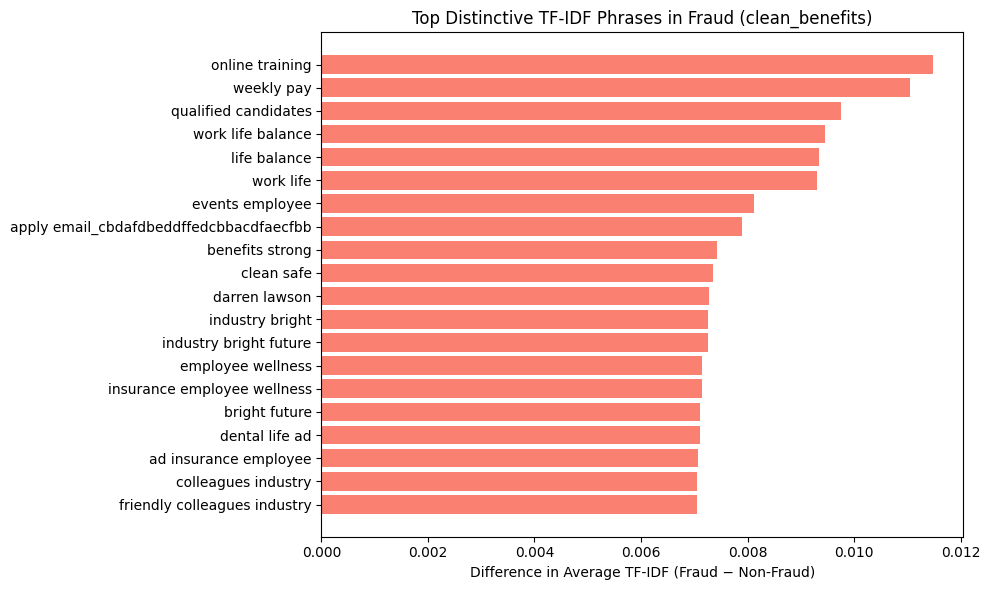

In [125]:
# Identify distinctive phrases using TF-IDF

# Columns to analyze
text_cols = ['clean_description', 'clean_requirements', 'clean_benefits']

for col in text_cols:
    # Full corpus
    corpus = df[col].tolist()
    
    # TF-IDF vectorizer for bigrams/trigrams
    vectorizer = TfidfVectorizer(ngram_range=(2,3), stop_words='english', max_features=5000)
    X = vectorizer.fit_transform(corpus)
    features = vectorizer.get_feature_names_out()
    
    # Fraud vs non-fraud split
    mask = df['fraudulent'].to_numpy() == 1
    X_fraud = X[mask]
    X_nonfraud = X[~mask]
    
    # Average TF-IDF per n-gram for fraud and non-fraud
    fraud_tfidf = X_fraud.mean(axis=0).A1
    nonfraud_tfidf = X_nonfraud.mean(axis=0).A1
    
    # Combine into DataFrame
    tfidf_df = pd.DataFrame({
        'ngram': features,
        'diff': fraud_tfidf - nonfraud_tfidf
    })
    
    # Sort by distinctiveness
    tfidf_df_sorted = tfidf_df.sort_values('diff', ascending=False).head(20)
    
    # --- Visualization only ---
    plt.figure(figsize=(10,6))
    plt.barh(tfidf_df_sorted['ngram'][::-1], tfidf_df_sorted['diff'][::-1], color="salmon")
    plt.title(f"Top Distinctive TF-IDF Phrases in Fraud ({col})")
    plt.xlabel("Difference in Average TF-IDF (Fraud − Non-Fraud)")
    plt.tight_layout()
    plt.show()


These plots show the top 20 phrases that are most distinctive in fraud postings compared to non-fraud postings, based on the difference in average TF-IDF scores. A higher positive value indicates that this phrase occurs more in fraud postings compared to non-fraud postings.

We observe the follow trends in the plots:

1) Work From Home and urgency cues: “work home”, “start immediately”

2) Basic skill requirements: “high school”, “basic computer”, “typing skills”

3) Financial or benefit incentives: “weekly pay”, “benefits strong”, “online training”

4) Luxury or aspirational language: “ultra luxury”, ”work life balance”, “industry bright future”


## Summary of key findings

Categorical features found to be most informative in distinguishing between scam job ads and legitimate postings:
1) Industry
2) Location
3) Has Company Logo
4) Has Company Profile 

Text Features including Job Description, Requirements and Benefits are also found to be informative in distinguishing between scam job ads and legitimate postings

# Proposed Solution

The proposed sequence of steps is as follows:

1) Data preprocessing - Handle missing values, Encode categorical variables, Concatenate text columns

2) Feature engineering - Text embedding (SBERT), create derived columns

3) Train test split and then run SMOTE-NC on the training dataset

For steps 1 to 3, more explanations will be included in the Data Preparation file.

4) Train LightGBM model on the training dataset and perform hyperparameter tuning. LightGBM model is chosen because:

    - Handles mixed data types well (Categorical, Text Embeddings)
    
    - Efficient with high dimensional data (Large number of features after text embedding)
    
    - Fast and Scalable: Optimized for large datasets and supports parallel learning
    
    - Provides Feature Importance: Helps to identify which features are most predictive of fraud. This explainability layer is important because if a posting is incorrectly flagged as fraudulent, we can communicate to the responsible party why the model made that decision. This supports transparency and trust in the system.
    
    Limitation:
    
    - High dimensional data (Text embeddings or many categorical features) can increase memory usage and training time. Depending on available resources, we may need to apply more aggressive dimensionality reduction or feature selection.

5) Model Evaluation - 3 main proposed metrics:
    
    - Recall (Priority): Measures how many actual fraudulent postings are correctly identified.
    
    - Precision: Measures how many predicted frauds are truly fraudulent, with low precision indicating many false alarms.
    
    - F1-score: Balances Recall and Precision into a single metric.
    
    Goal: High recall, high precision and strong F1-score
    
    Challenge: Trade-off between recall and precision. 
    
    Solution: Prioritize maximizing recall (to catch as many fraud cases as possible) and utilize Precision-Recall (PR) curve to select an optimal threshold for classifying fraudulent cases.
    
6) Before deployment:

    Perform cross-validation to assess model performance using proposed metrics (Recall, Precision, F1-score)

    Benchmark against prior fraud detection models or published research on job fraud detection

    Validate model on real-time data before deployment, including manual checks on flagged job postings.

7) After deployment:

    Track performance metrics over time (Recall, Precision) to ensure the model remains reliable and effective.

    Periodically update or retrain model to adapt to emerging fraud patterns and new data trends.
    